In [1]:
import fasttext
import fasttext.util

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import pandas as pd
import numpy as np

In [3]:
import nltk
import re
from nltk.tokenize import word_tokenize

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [6]:
from tqdm.notebook import tqdm

In [115]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.manual_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

In [116]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [8]:
fasttext.util.download_model('en', if_exists='ignore')

'cc.en.300.bin'

In [9]:
ft_model = fasttext.load_model('cc.en.300.bin')

In [117]:
train_df = pd.read_csv('data/train_balanced.csv') 
val_df = pd.read_csv('data/validation_df.csv')
test_df = pd.read_csv('data/test_df.csv')

In [118]:
label_map = {'bad': 0, 'neutral': 1, 'good': 2}

In [119]:
train_df['Label'] = train_df['Score'].map(label_map)
val_df['Label'] = val_df['Score'].map(label_map)
test_df['Label'] = test_df['Score'].map(label_map)

In [120]:
train_df.head()

,Score,Text,Cleaned_Text,Label
0,good,THIS PRODUCT WAS DELIVERED FASTER THAN EXPECTE...,this product be deliver faster than expect so ...,2
1,bad,We couldn't drink this -- both my husband and ...,we couldn t drink this both my husband and my ...,0
2,neutral,Great price<br />Great taste<br />Fatty food<b...,great price great taste fatty food quick deliv...,1
3,good,And I love the nice storage tub. If I get catn...,and i love the nice storage tub if i get catni...,2
4,bad,I bought the exact same product in the superma...,i bought the exact same product in the superma...,0


In [121]:
def clean_and_tokenize(text):
    text = str(text).lower()
    
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    
    return tokens

In [122]:
train_tokens = [clean_and_tokenize(t) for t in train_df['Text']]
val_tokens   = [clean_and_tokenize(t) for t in val_df['Text']]
test_tokens  = [clean_and_tokenize(t) for t in test_df['Text']]

In [123]:
all_train_tokens = [word for tokens in train_tokens for word in tokens]
word_counter = Counter(all_train_tokens)

In [124]:
len(word_counter)

21277

In [125]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

In [126]:
max_vocab_size = 10000
most_common = word_counter.most_common(max_vocab_size)

In [127]:
vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for idx, (word, freq) in enumerate(most_common, start=2):
    vocab[word] = idx

In [128]:
print('Vocabulary size:', len(vocab))

Vocabulary size: 10002


In [129]:
class TextDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab, max_len=50):
        self.max_len = max_len
        
        processed_indices = []
        for tokens in tokenized_texts:
            indices = [vocab.get(w, 1) for w in tokens]
            
            indices = indices[:max_len] + [0] * max(0, max_len - len(indices))
            
            processed_indices.append(indices)
            
        self.texts = torch.tensor(processed_indices, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [130]:
MAX_LEN = 50

train_dataset = TextDataset(train_tokens, train_df['Label'], vocab, max_len=MAX_LEN)
val_dataset = TextDataset(val_tokens, val_df['Label'], vocab, max_len=MAX_LEN)
test_dataset = TextDataset(test_tokens, test_df['Label'], vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,generator=g)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [131]:
EMBEDDING_DIM = ft_model.get_dimension()

In [132]:
vocab_size = len(vocab)

In [133]:
embedding_matrix = torch.zeros((vocab_size, EMBEDDING_DIM))
for word, idx in vocab.items():
    if word == PAD_TOKEN:
        continue
    vec = ft_model.get_word_vector(word)
    embedding_matrix[idx] = torch.tensor(vec)

In [134]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers,embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(embedding_matrix)
            self.embedding.weight.requires_grad = True # da se FastText menja tokom učenja
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, 
                            batch_first=True, dropout=0.2 if n_layers > 1 else 0.0
                            ,bidirectional=True)
        
        self.dropout = nn.Dropout(0.2)
        # *2 jer je bidirekcioni
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        
        x = output[:, -1, :] 
        x = self.dropout(x)
        return self.fc(x)

In [135]:
def train_model(model, optimizer,scheduler, train_loader, valid_loader, epochs=5,save_path='models/best_LSTM.pth'):    
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_f1' : [],
        'train_steps': [],
        'valid_loss': [],
        'valid_accuracy': [],
        'valid_f1': [],
        'valid_steps': [],
    }

    step = 0
    best_val_f1 = 0.0

    
    for epoch in range(epochs):
        model.train()
        train_loss_epoch = 0
        train_correct = 0
        train_samples = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = labels.size(0)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, predicted = torch.max(outputs, 1)
            correct = (predicted == labels).sum().item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(correct / batch_size)
            metrics['train_steps'].append(step)

    
            train_loss_epoch += loss.item() * batch_size
            train_correct += correct
            train_samples += batch_size

            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

            step += 1
            
        
        train_loss = train_loss_epoch / train_samples
        train_accuracy = train_correct / train_samples
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        metrics['train_f1'].append(train_f1)
            
        model.eval()
        with torch.no_grad():
            valid_loss_total = 0
            valid_correct = 0
            valid_samples = 0
            val_preds = []
            val_labels = []
            
            for inputs, labels in tqdm(valid_loader, desc=f"Epoha {epoch+1}/{epochs} [Valid]"):
                inputs, labels = inputs.to(device), labels.to(device)
                batch_size = labels.size(0)
            
                outputs = model(inputs)
                loss = nn.CrossEntropyLoss(reduction='sum')(outputs, labels)
                
                _, predicted = torch.max(outputs, 1)
                correct = (predicted == labels).sum().item()
                
                valid_loss_total += loss.item()
                valid_correct += correct
                valid_samples += batch_size
                
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

            valid_loss = valid_loss_total / valid_samples
            valid_accuracy = valid_correct / valid_samples
            valid_f1 = f1_score(val_labels, val_preds, average='macro')

            scheduler.step(valid_f1)
            
            if valid_f1 > best_val_f1:
                best_val_f1 = valid_f1
    
                torch.save(model.state_dict(), save_path)
                
            metrics['valid_loss'].append(valid_loss)
            metrics['valid_accuracy'].append(valid_accuracy)
            metrics['valid_f1'].append(valid_f1)
            metrics['valid_steps'].append(step)

        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} - Train Acc: {train_accuracy:.4f} | Val Loss: {valid_loss:.4f} - Val Acc: {valid_accuracy:.4f} - Val F1 (Macro): {valid_f1:.4f}")
        
    return metrics

In [136]:
def plot_all_metrics(metrics):
    epochs = range(1, len(metrics['valid_loss']) + 1)

    plt.figure(figsize=(18, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss (per batch)', color='blue', alpha=0.3)
    plt.plot(metrics['valid_steps'], metrics['valid_loss'], label='Validation Loss', color='orange', marker='s', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Loss Curves (Steps)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy (po batch-evima)', color='blue', alpha=0.3)
    plt.plot(metrics['valid_steps'], metrics['valid_accuracy'], label='Validation Accuracy', color='purple', marker='s', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. F1-Score Plot
    plt.subplot(1, 3, 3)
    plt.plot(epochs, metrics['train_f1'], 'o-', label='Train F1 (Macro)', color='blue')
    plt.plot(epochs, metrics['valid_f1'] if 'valid_f1' in metrics else metrics.get('valid_accuracy'), 's-', label='Val F1 (Macro)', color='green', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Macro F1-Score Across Epochs')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [138]:
def evaluate_and_plot_confusion_matrix(model, valid_loader,model_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    class_names = ['Bad', 'Neutral', 'Good']
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

In [139]:
vocab_size = len(vocab)  
EMBEDDING_DIM = 300      
HIDDEN_DIM = 128         
OUTPUT_DIM = 3           
N_LAYERS = 2 

model = SentimentLSTM(
    vocab_size=vocab_size, 
    embedding_dim=EMBEDDING_DIM, 
    hidden_dim=HIDDEN_DIM, 
    output_dim=OUTPUT_DIM, 
    n_layers=N_LAYERS, 
    embedding_matrix=embedding_matrix  
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

metrics = train_model(
    model=model, 
    optimizer=optimizer,
    scheduler = scheduler,
    train_loader=train_loader,  
    valid_loader=val_loader,  
    epochs=5  ,
    save_path='models/best_LSTM_v1.pth'
)

Epoch 1/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 1/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 1.0795 - Train Acc: 0.3763 | Val Loss: 1.0207 - Val Acc: 0.4936 - Val F1 (Macro): 0.2977


Epoch 2/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 2/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoha 4/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.4226 - Train Acc: 0.8407 | Val Loss: 0.3593 - Val Acc: 0.8662 - Val F1 (Macro): 0.7303


Epoch 5/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 5/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.3215 - Train Acc: 0.8857 | Val Loss: 0.3392 - Val Acc: 0.8792 - Val F1 (Macro): 0.7501


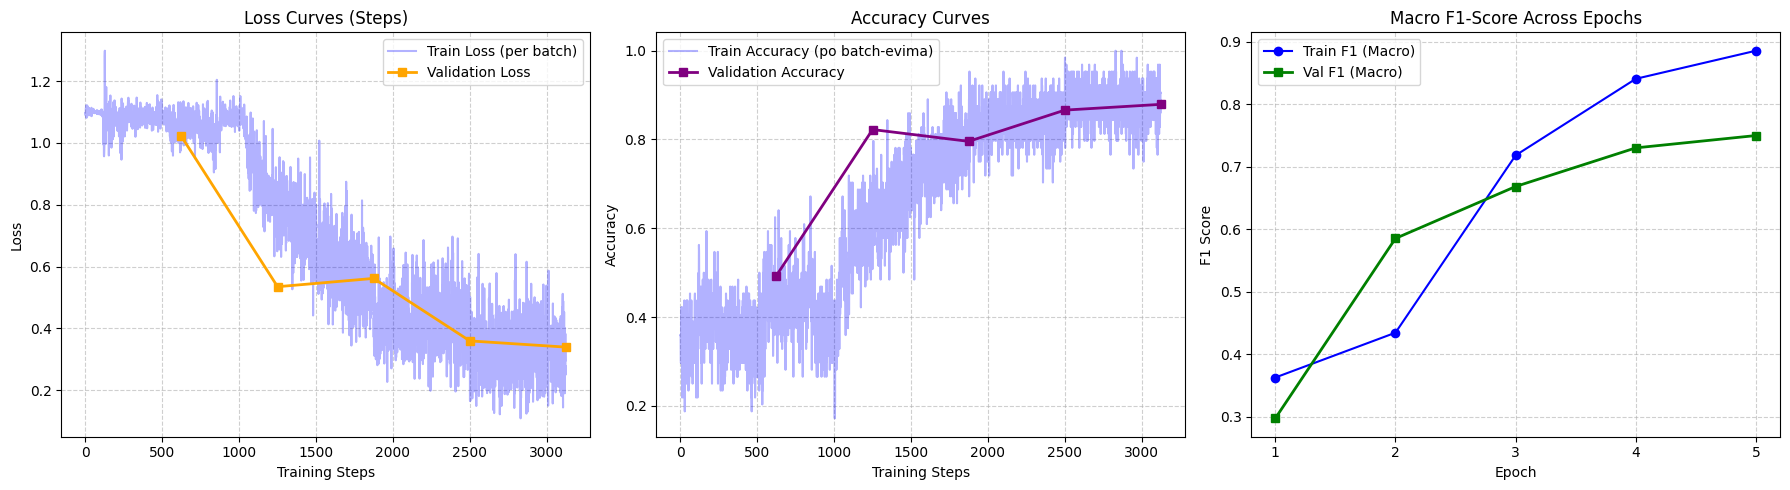

In [140]:
plot_all_metrics(metrics)

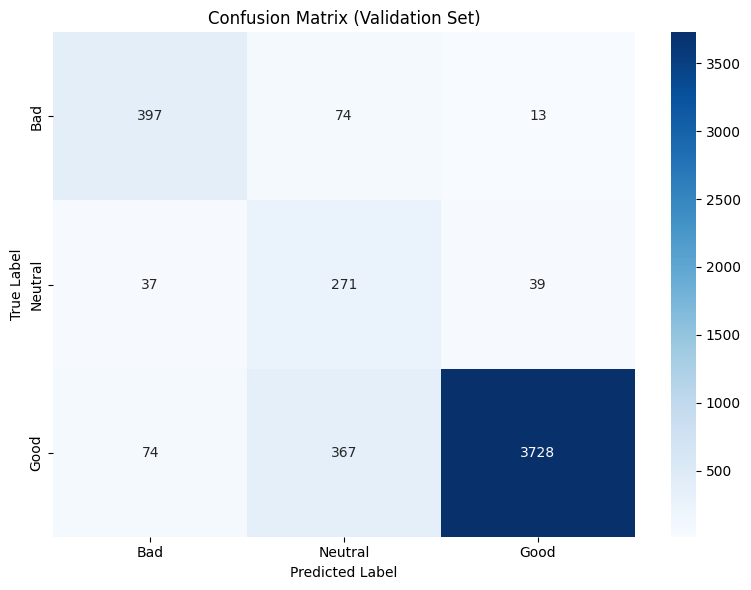


Classification Report:
              precision    recall  f1-score   support

         Bad       0.78      0.82      0.80       484
     Neutral       0.38      0.78      0.51       347
        Good       0.99      0.89      0.94      4169

    accuracy                           0.88      5000
   macro avg       0.72      0.83      0.75      5000
weighted avg       0.92      0.88      0.90      5000



In [141]:
evaluate_and_plot_confusion_matrix(model, val_loader, 'models/best_LSTM_v1.pth')

In [142]:
model.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model.to(device)

SentimentLSTM(
  (embedding): Embedding(10002, 300, padding_idx=0)
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

In [143]:
fine_tune_optimizer = optim.Adam(
    model.parameters(), 
    lr=0.0005,             
    weight_decay=1e-3     
)
fine_tune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(fine_tune_optimizer, mode='max', factor=0.5, patience=1)

In [144]:
fine_tune_metrics = train_model(
    model=model, 
    optimizer=fine_tune_optimizer, 
    scheduler=fine_tune_scheduler, 
    train_loader=train_loader, 
    valid_loader=val_loader, 
    epochs=5,
    save_path='models/best_LSTM_v2.pth'
)

Epoch 1/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 1/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 0.3494 - Train Acc: 0.8728 | Val Loss: 0.3175 - Val Acc: 0.8884 - Val F1 (Macro): 0.7486


Epoch 2/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 2/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoha 4/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.3778 - Train Acc: 0.8599 | Val Loss: 0.4703 - Val Acc: 0.8396 - Val F1 (Macro): 0.7013


Epoch 5/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 5/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.3605 - Train Acc: 0.8678 | Val Loss: 0.3458 - Val Acc: 0.8720 - Val F1 (Macro): 0.7416


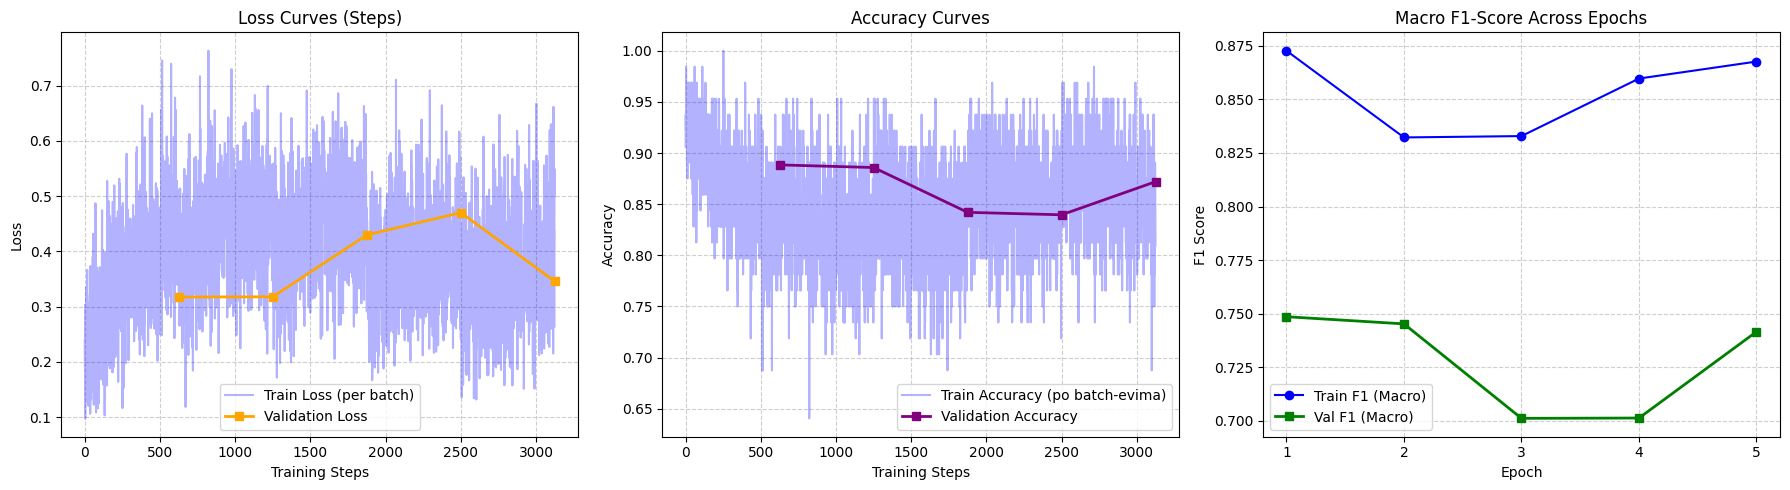

In [145]:
plot_all_metrics(fine_tune_metrics)

Since this fine-tuning step fails to improve performance on both the training and validation sets, we will repeat the process without additional regularization (weight_decay removed).

In [146]:
model.load_state_dict(torch.load('models/best_LSTM_v1.pth', map_location=device))
model.to(device)

SentimentLSTM(
  (embedding): Embedding(10002, 300, padding_idx=0)
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

In [147]:
fine_tune_optimizer2 = optim.Adam(
    model.parameters(), 
    lr=0.0005            
)
fine_tune_scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(fine_tune_optimizer, mode='max', factor=0.5, patience=1)

In [149]:
fine_tune_metrics2 = train_model(
    model=model, 
    optimizer=fine_tune_optimizer2, 
    scheduler=fine_tune_scheduler2, 
    train_loader=train_loader, 
    valid_loader=val_loader, 
    epochs=5,
    save_path='models/best_LSTM_v3.pth'
)

Epoch 1/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 1/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/5] | Train Loss: 0.2284 - Train Acc: 0.9229 | Val Loss: 0.4048 - Val Acc: 0.8710 - Val F1 (Macro): 0.7443


Epoch 2/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 2/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoha 4/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [4/5] | Train Loss: 0.1261 - Train Acc: 0.9636 | Val Loss: 0.5390 - Val Acc: 0.8634 - Val F1 (Macro): 0.7256


Epoch 5/5 [Train]:   0%|          | 0/625 [00:00<?, ?it/s]

Epoha 5/5 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [5/5] | Train Loss: 0.1058 - Train Acc: 0.9702 | Val Loss: 0.5649 - Val Acc: 0.8592 - Val F1 (Macro): 0.7272


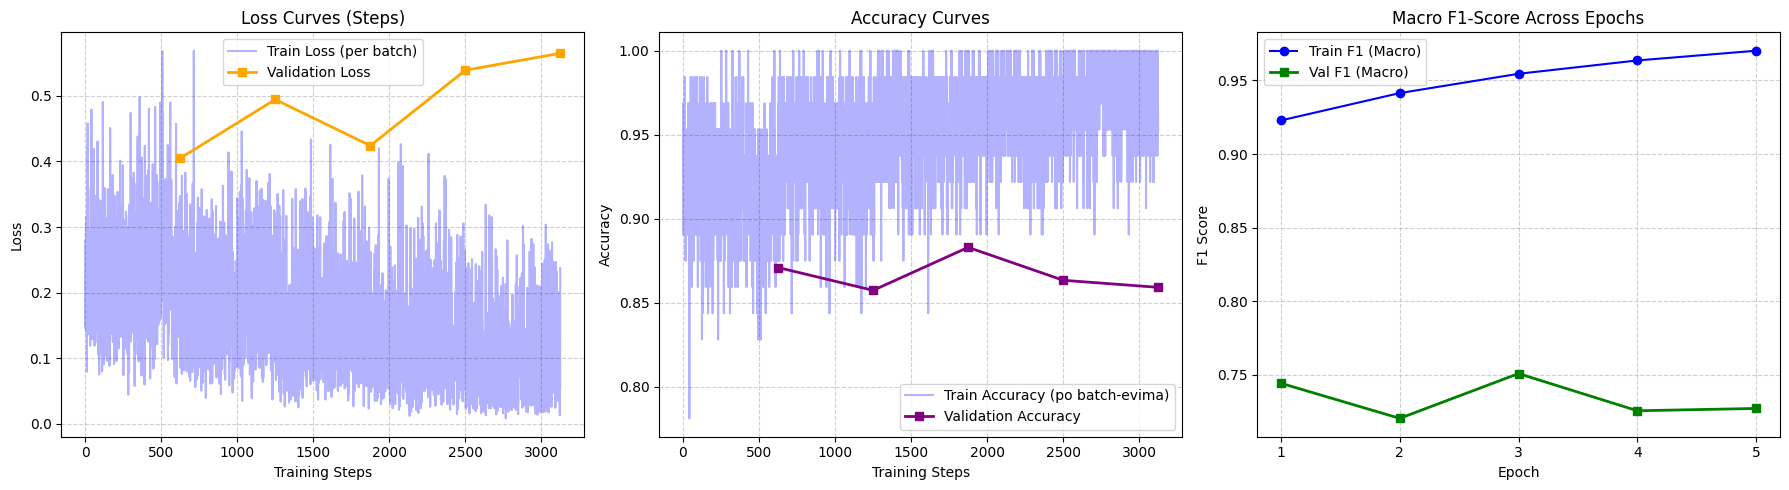

In [150]:
plot_all_metrics(fine_tune_metrics2)

While we observe that train loss decreases and train accuracy increases, the same does not happen on the validation set, where the loss increases and accuracy stagnates, or even slightly decreases.
The F1-score on the training set grows toward 1, while the F1-score on the validation set does not change significantly.
These are clear signs of overfitting, so for the final model, we will choose the one that performed best before fine-tuning.

# Evaluation on test dataset

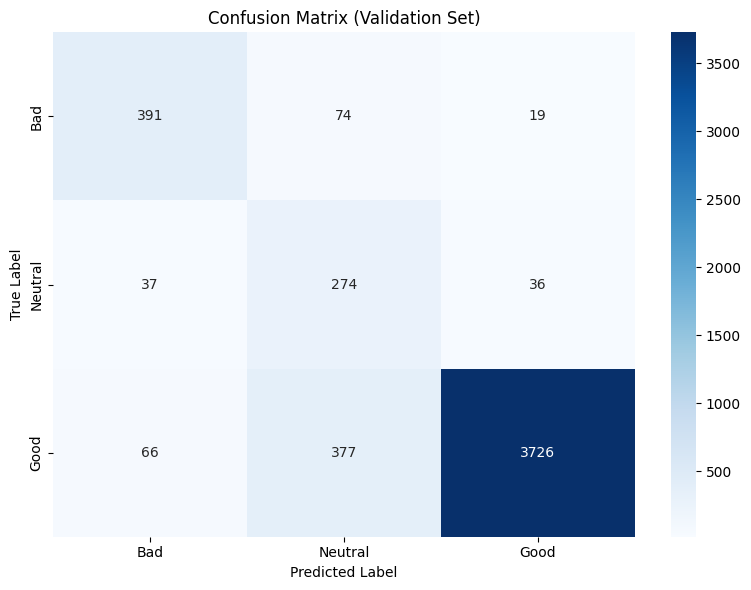


Classification Report:
              precision    recall  f1-score   support

         Bad       0.79      0.81      0.80       484
     Neutral       0.38      0.79      0.51       347
        Good       0.99      0.89      0.94      4169

    accuracy                           0.88      5000
   macro avg       0.72      0.83      0.75      5000
weighted avg       0.92      0.88      0.89      5000



In [155]:
evaluate_and_plot_confusion_matrix(model, test_loader,model_path='models/best_LSTM_v1.pth')

We observe similar results to the validation set, with both achieving an accuracy of 0.88 and an F1-score of 0.75. Notably, the precision for the neutral class is very low (0.38) in both cases, indicating that the model struggles to correctly identify and isolate neutral reviews.

Wrong predicted examples

In [175]:
model.eval()
all_preds = []
all_labels = []

target_loader = test_loader 

with torch.no_grad():
    for inputs, labels in target_loader:
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [176]:
errors = np.where(all_labels != all_preds)[0]

In [177]:
for idx in specific_errors[:5]:
    text_rec = test_df.iloc[idx]['Text'] 
    
    print(text_rec)
    print(f"True class: {all_labels[idx]} | Predicted class: {all_preds[idx]}")
    print("-" * 50)

I was looking for 'apple crisps' but didn't want artificial ingredients or sugar added.  These fit the bill! Deliciously tart and semi- sweet.  Crisp enough but still a bit chewy...the best part?  My kids HATE them! Yum, Yum...more for me:-)
True class: 2 | Predicted class: 1
--------------------------------------------------
I got these cheese grits! they were great, except for the fact they tasted like STAMPS!!!! STAMPS I TELL YOU! STAMPS! I would definitely buy again though! and so should you!
True class: 2 | Predicted class: 1
--------------------------------------------------
I just called smuckers directly 1-800-742-6729  and ordered 6 bags. It is a great coffee and not sure why the smuckers people do not make more of it
True class: 2 | Predicted class: 1
--------------------------------------------------
Love the Popchips.  Less calories then regular chips, so you can eat more.  Cheddar kinda tastes like a white cheddar to me.
True class: 2 | Predicted class: 1
-----------------

Despite class balancing, the model still struggles because it gets confused by sarcasm and mixed sentiments within the same review. For instance, the model incorrectly classifies positive reviews as neutral because it reacts to isolated words like "Hates" even when the rest of the sentence is playful and positive (“My kids HATE them... more for me”) or words like "kinda" while discussing minor flaws, despite the overall review being explicitly positive.